In [ ]:
from datasets import load_dataset

import re
import spacy
from string import punctuation
from collections import defaultdict

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt

import nltk
nltk.download('words', quiet=True)
from nltk.corpus import words as nltk_words

In [2]:
raw = load_dataset("csv", data_files="cw_data.csv", column_names=["text", "label"])
dataset = raw["train"]

In [ ]:
def levenshtein_distance(s, t, max_dist=None):
    """Compute minimum edit distance between two strings using the
    Wagner-Fischer dynamic-programming algorithm.
    
    Operations (each cost 1): insertion, deletion, substitution.
    
    Recurrence:
        D[i][0] = i                              (delete all of s)
        D[0][j] = j                              (insert all of t)
        D[i][j] = D[i-1][j-1]                    if s[i] == t[j]
                 = 1 + min(D[i-1][j],            deletion
                           D[i][j-1],            insertion
                           D[i-1][j-1])          substitution
    
    Uses O(min(m,n)) space via a two-row optimisation — only the previous
    and current rows are kept. Optional early termination when max_dist is
    set and the minimum value in any row exceeds the threshold.
    
    Time:  O(m * n)   Space: O(min(m, n))
    """
    if len(s) < len(t):
        s, t = t, s
    m, n = len(s), len(t)
    
    if max_dist is not None and abs(m - n) > max_dist:
        return max_dist + 1
    
    prev = list(range(n + 1))
    for i in range(1, m + 1):
        curr = [i] + [0] * n
        row_min = curr[0]
        for j in range(1, n + 1):
            if s[i - 1] == t[j - 1]:
                curr[j] = prev[j - 1]
            else:
                curr[j] = 1 + min(prev[j], curr[j - 1], prev[j - 1])
            row_min = min(row_min, curr[j])
        if max_dist is not None and row_min > max_dist:
            return max_dist + 1
        prev = curr
    return prev[n]


def build_vocabulary(normalisation_map):
    """Build a reference vocabulary for spelling correction from three sources:
    1. Filtered NLTK words corpus (lowercase, alphabetic, length 3-15)
    2. Domain-specific customer support terms
    3. Target forms from the normalisation map
    
    Returns the vocabulary set and a length-indexed dict for efficient lookup.
    """
    # NLTK English words — filtered to lowercase alphabetic entries
    base_vocab = {w.lower() for w in nltk_words.words()
                  if w.isalpha() and w == w.lower() and 3 <= len(w) <= 15}
    
    # Domain terms from class labels and common customer support vocabulary
    domain_terms = {
        'email', 'password', 'account', 'login', 'subscription',
        'refund', 'billing', 'tracking', 'shipping', 'checkout',
        'notification', 'privacy', 'authentication', 'recovery',
        'signup', 'username', 'paypal', 'coupon', 'promo',
    }
    
    # Normalisation map target forms (flatten multi-word values)
    norm_targets = set()
    for target in normalisation_map.values():
        norm_targets.update(target.split())
    
    vocab = base_vocab | domain_terms | norm_targets
    
    # Index by word length for O(1) length-bucket lookups
    vocab_by_length = defaultdict(set)
    for w in vocab:
        vocab_by_length[len(w)].add(w)
    
    return vocab, vocab_by_length

In [ ]:
class LemmaCleaner:  
    # Same domain-specific normalisation map as the BOW approach, built from
    # manual inspection of the dataset. Applied identically so the two pipelines
    # differ only in their linguistic processing (stemming vs lemmatisation)
    # and vectorisation strategy (TF-IDF vs sentence embeddings).
    NORMALISATION_MAP = {
        # Abbreviations — customer support shorthand
        'acct': 'account',    # ~45 occurrences
        'accts': 'accounts',  # 1 occurrence
        'pls': 'please',      # ~12 occurrences
        'plz': 'please',
        'pwd': 'password',    # 1 occurrence
        'wout': 'without',    # w/out after punctuation removal
        # Typos — recurring misspellings
        'emial': 'email',     # 8 occurrences
        # Textspeak
        'wat': 'what',        # ~38 occurrences
        # Number-for-word substitutions
        '2': 'to',            # ~30 occurrences
        # Contractions missing apostrophes (apostrophe stripped in punctuation step)
        'cant': 'cannot',     # 7 occurrences — expands so negation is preserved
        'didnt': 'did not',   # 1 occurrence
        'doesnt': 'does not',
        'dont': 'do not',
        'wont': 'will not',
        'isnt': 'is not',
    }

    def __init__(self, data, normalise=True, spell_correct=True):
        self.data = data
        self.nlp = spacy.load("en_core_web_sm")
        self.negations = {'not', 'no', 'cannot'}
        self.stop_words = set(self.nlp.Defaults.stop_words) - self.negations
        self.corrections_log = []

        # Build vocabulary once (used by spell correction)
        self.vocab, self.vocab_by_length = build_vocabulary(self.NORMALISATION_MAP)

        self.lowered = self.lowercase(self.data)
        self.punctuated = self.remove_punctuation(self.lowered)
        self.normalised = self.normalise_text(self.punctuated) if normalise else self.punctuated
        self.spell_corrected = self.correct_spelling(self.normalised) if spell_correct else self.normalised
        self.lemmatised = self.tokenise_and_lemmatise(self.spell_corrected)
        self.rejoined = self.rejoin(self.lemmatised)

    def lowercase(self, texts):
        return [t.lower() for t in texts]
    
    def remove_punctuation(self, texts):
        extra = '—–""''…' 
        all_punct = punctuation + extra
        cleaned_texts = []
        for t in texts:
            t = t.translate(str.maketrans('', '', all_punct))
            cleaned_texts.append(t)
        return cleaned_texts
    
    def normalise_text(self, texts):
        """Replace domain-specific abbreviations, typos, and textspeak with 
        standard forms. Applied after punctuation removal so that contractions
        like can't → cant are caught by the 'cant' → 'cannot' mapping.
        Uses word-boundary regex to avoid partial matches (e.g. '2' in '24')."""
        normalised = []
        for t in texts:
            for informal, formal in self.NORMALISATION_MAP.items():
                t = re.sub(r'\b' + re.escape(informal) + r'\b', formal, t)
            normalised.append(t)
        return normalised
    
    def correct_spelling(self, texts):
        """Correct residual misspellings not handled by the normalisation map
        using minimum Levenshtein edit distance against a reference vocabulary.
        
        Operates at the string level (before formal tokenisation) using simple
        whitespace splitting. This is safe because punctuation is already removed.
        
        Safeguards against false corrections:
        - Skip words already in the vocabulary (no correction needed)
        - Skip words ≤ 3 characters (too many false positives)
        - Skip non-alphabetic tokens (numerics, mixed alphanumeric)
        - Skip known abbreviations from the normalisation map
        - Length-dependent thresholds: max_dist=1 for 4-5 char, max_dist=2 for 6+
        """
        skip_words = set(self.NORMALISATION_MAP.keys())
        corrected_texts = []
        
        for text in texts:
            tokens = text.split()
            corrected_tokens = []
            for word in tokens:
                if (word in self.vocab or word in skip_words
                        or len(word) <= 3 or not word.isalpha()):
                    corrected_tokens.append(word)
                    continue
                
                max_dist = 1 if len(word) <= 5 else 2
                
                # Search candidates within reachable length range
                candidates = set()
                for length in range(len(word) - max_dist, len(word) + max_dist + 1):
                    candidates |= self.vocab_by_length.get(length, set())
                
                best_word, best_dist = word, max_dist + 1
                for candidate in candidates:
                    d = levenshtein_distance(word, candidate, max_dist=max_dist)
                    if d < best_dist:
                        best_dist = d
                        best_word = candidate
                
                if best_word != word:
                    self.corrections_log.append((word, best_word, best_dist))
                corrected_tokens.append(best_word)
            
            corrected_texts.append(' '.join(corrected_tokens))
        return corrected_texts
    
    def remove_standalone_numerics(self, tokenised_texts):
        cleaned = []
        for t in tokenised_texts:
            cleaned.append([w for w in t if not re.fullmatch(r'\d+', w)])
        return cleaned
    
    def remove_stop_words(self, tokenised_texts):
        cleaned_texts = []
        for t in tokenised_texts:
            cleaned_texts.append([w for w in t if w not in self.stop_words])
        return cleaned_texts
    
    def tokenise_and_lemmatise(self, texts):
        result = []
        for t in texts:
            doc = self.nlp(t)
            tokens = [token.lemma_ for token in doc
                    if token.text not in self.stop_words
                    and not re.fullmatch(r'\d+', token.text)
                    and token.text.strip()]
            result.append(tokens)
        return result
    
    def rejoin(self, lemmatised_texts):
        return [' '.join(tokens) for tokens in lemmatised_texts]

In [ ]:
parsed = LemmaCleaner(dataset["text"])

# Display spelling corrections applied
if parsed.corrections_log:
    from collections import Counter
    correction_counts = Counter(parsed.corrections_log)
    print(f"Spelling corrections applied ({len(parsed.corrections_log)} total):")
    for (orig, corrected, dist), count in correction_counts.most_common():
        print(f"  '{orig}' → '{corrected}' (distance={dist}, ×{count})")
else:
    print("No spelling corrections applied.")

In [5]:
parsed.lemmatised[:5]

[['tracking', 'show', 'ship', 'no', 'delivery', 'help', 'pls'],
 ['partial', 'shipment', 'track', 'separately'],
 ['invalid', 'email', 'enter', 'wat', 'happen'],
 ['recover', 'acct', 'suspend'],
 ['emial', 'update', 'fail', 'error', 'fix']]

In [6]:
vectoriser = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = vectoriser.encode(parsed.rejoined)
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42, stratify=y
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                         precision    recall  f1-score   support

       account_recovery       1.00      1.00      1.00         4
        billing_history       1.00      1.00      1.00         4
           data_privacy       1.00      1.00      1.00         4
         delete_account       1.00      1.00      1.00         5
            login_issue       1.00      1.00      1.00         3
  notification_settings       1.00      1.00      1.00         5
         order_tracking       1.00      0.75      0.86         4
          payment_issue       1.00      0.86      0.92         7
         refund_request       0.75      0.75      0.75         4
         reset_password       1.00      1.00      1.00         4
         shipping_delay       0.86      1.00      0.92         6
subscription_management       0.83      1.00      0.91         5
        two_factor_auth       1.00      1.00      1.00         2
           update_email       1.00      1.00      1.00         5

               accuracy

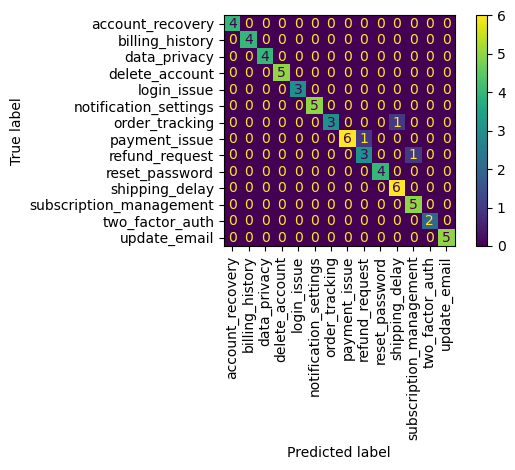

Macro F1: 0.916 (+/- 0.031)


In [7]:
model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'    # handles your imbalanced classes
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
# Add to Semantic notebook
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=90)
plt.tight_layout()
plt.show()
scores = cross_val_score(model, embeddings, y, cv=5, scoring='f1_macro')
print(f"Macro F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

In [8]:
errors = [(text, true, pred) 
          for text, true, pred in zip(dataset["text"], y_test, y_pred) 
          if true != pred]

for text, true, pred in errors:
    print(f"Text: {text}")
    print(f"True: {true} | Predicted: {pred}\n")

Text: Can I reset my password if my account is locked or do I need support?
True: order_tracking | Predicted: shipping_delay

Text: billing history not updating… wat do?
True: payment_issue | Predicted: refund_request

Text: cant pay with credit card immediately?
True: refund_request | Predicted: subscription_management



## Ablation Study: Two-Tier Preprocessing Impact

The preprocessing pipeline has two complementary layers:
1. **Normalisation map** (deterministic) — handles known abbreviations, textspeak, and typos
2. **Spell correction** (heuristic) — catches unknown misspellings via Levenshtein distance

We hypothesise that both layers have a **smaller** impact on the semantic pipeline
than on BOW, because sentence-transformers capture meaning through subword context
even when surface forms are misspelled.

In [ ]:
configs = {
    'Baseline (no norm, no spell)':      {'normalise': False, 'spell_correct': False},
    'Normalisation only':                 {'normalise': True,  'spell_correct': False},
    'Spell correction only':              {'normalise': False, 'spell_correct': True},
    'Both (full pipeline)':               {'normalise': True,  'spell_correct': True},
}

results = {}
for name, kwargs in configs.items():
    parsed_abl = LemmaCleaner(dataset["text"], **kwargs)
    
    embeddings_abl = vectoriser.encode(parsed_abl.rejoined)
    X_tr, X_te, y_tr, y_te = train_test_split(
        embeddings_abl, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model_abl = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    )
    model_abl.fit(X_tr, y_tr)
    
    scores = cross_val_score(model_abl, embeddings_abl, y, cv=5, scoring='f1_macro')
    results[name] = (scores.mean(), scores.std())
    print(f"  {name:40s} — Macro F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

# Bar chart comparison
names = list(results.keys())
means = [results[n][0] for n in names]
stds  = [results[n][1] for n in names]

plt.figure(figsize=(10, 4))
plt.barh(names, means, xerr=stds, capsize=5, color=['#d9d9d9', '#93c4d1', '#93c4d1', '#3a86a8'])
plt.xlabel('Macro F1 (5-fold CV)')
plt.title('Semantic Pipeline: Preprocessing Ablation Study')
plt.xlim(0.75, 1.0)
plt.tight_layout()
plt.show()